# Notebook 03 - Modélisation et Optimisation XGBoost

**Objectif** :  
Ce troisième notebook construit le modèle de prédiction du prix médian des maisons d'un quartier en utilisant XGBoost, un algorithme de gradient boosting très performant. L'objectif est d'atteindre un **R² > 0.80** tout en garantissant une bonne généralisation grâce à une validation rigoureuse.

**Pourquoi XGBoost ?**
- **Performance élevée** : l'un des meilleurs algorithmes pour la régression sur données tabulaires
- **Robuste aux distributions et outliers** : ne nécessite pas de normalisation stricte
- **Capture automatiquement les interactions** : pas besoin de les créer toutes manuellement (même si les créer aide à capter les intéractions)
- **Régularisation intégrée** : limite l'overfitting
- **Feature importance native** : facilite l'interprétation

**Livrables attendus** :
- Modèle XGBoost optimisé avec R² > 0.80
- Sélection des features les plus importantes
- Validation croisée robuste (5-fold CV)
- Analyse de la généralisation (train vs test)
- Pipeline de prédiction reproductible

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import joblib
import json
from datetime import datetime
import os

df = pd.read_csv('../data/preprocessed/02_housing_model.csv')
print(f"Shape: {df.shape}")

Shape: (19664, 37)


## 1. Stratégie de Validation : Cross-Validation

### 1.1 Fonction split_train_cv()

**Architecture** :
- **Split train (80%) / test (20%)** : séparation initiale
- **Cross-validation 5-fold sur train** : estimation robuste des performances
- **Test reste isolé** : mesure la vraie capacité de généralisation

**Avantages** :
- Évite l'overfitting grâce à la validation croisée
- Le test set n'est jamais vu pendant l'entraînement
- Estimation fiable de la performance réelle

### 1.2 Paramètres XGBoost (Baseline)

**Paramètres choisis** :
- `n_estimators = 800` : nombre d'arbres (plus = meilleur, mais risque d'overfit)
- `learning_rate = 0.03` : taux d'apprentissage faible = apprentissage lent mais précis
- `max_depth = 8` : profondeur maximale des arbres (contrôle la complexité)
- `min_child_weight = 3` : régularisation (évite l'overfitting sur petits groupes)
- `subsample = 0.8` : 80% des données par arbre (randomisation pour robustesse)
- `colsample_bytree = 0.8` : 80% des features par arbre (évite dépendance à quelques variables)
- `gamma = 0.1` : seuil de gain minimum pour split (arbres conservateurs)
- `reg_alpha = 0.1` : régularisation L1 (pénalise features inutiles)
- `reg_lambda = 1.0` : régularisation L2 (lisse les poids)

**Réglages** :
- Configuration **conservatrice** pour éviter l'overfitting
- Équilibre entre **performance** et **généralisation**
- Paramètres standards pour un premier benchmark

In [17]:
def split_train_cv(df):
    
    X = df.drop('median_house_value', axis=1)
    y = df['median_house_value']
    
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    print(f"Split des données:")
    print(f"  Train+Val: {X_trainval.shape[0]:,} samples (80%)")
    print(f"  Test:      {X_test.shape[0]:,} samples (20%)")
    
    model = xgb.XGBRegressor(
        n_estimators=800,
        learning_rate=0.03,
        max_depth=8,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0.1,
        reg_alpha=0.1,
        reg_lambda=1.0,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    )

    cv_scores = cross_val_score(
        model, X_trainval, y_trainval,
        cv=5,
        scoring='r2',
        n_jobs=-1
    )
    
    print(f"\nR² scores par fold: {cv_scores}")
    print(f"R² moyen: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    
    model.fit(X_trainval, y_trainval)
    
    y_pred_test = model.predict(X_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2_test = r2_score(y_test, y_pred_test)

    print("\nPERFORMANCE FINALE SUR TEST SET :")
    print(f"RMSE: {rmse_test:,.0f}")
    print(f"R²:   {r2_test:.4f}")
    
    return X, model

X, model = split_train_cv(df)

Split des données:
  Train+Val: 15,731 samples (80%)
  Test:      3,933 samples (20%)

R² scores par fold: [0.82590827 0.8214111  0.81909544 0.83905146 0.83719779]
R² moyen: 0.8285 (+/- 0.0163)

PERFORMANCE FINALE SUR TEST SET :
RMSE: 40,109
R²:   0.8351


**Observations** :
- Les scores R² sont **très stables entre les folds** (écart-type faible)
- Cela indique que le modèle **généralise bien** et n'est pas sensible au découpage des données
- Un **R² moyen de 0.8285** sur la cross-validation est très satisfaisant pour une baseline

**Résultat** :  
**Objectif atteint** : R² > 0.80 dès le modèle baseline

## 2. Feature Importance

**Objectif** :  
Analyser l'importance des features avec XGBoost pour identifier les variables clés et potentiellement **simplifier le modèle**.

Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5
Iteration 6
Iteration 7
Iteration 8
Iteration 9
Iteration 10
Iteration 11
Iteration 12
Iteration 13
Iteration 14
Iteration 15
Iteration 16
Iteration 17
Iteration 18
Iteration 19
Iteration 20
Iteration 21
Iteration 22
Iteration 23
Iteration 24
Iteration 25
Iteration 26
Iteration 27
Iteration 28
Iteration 29
Iteration 30
Iteration 31
Iteration 32
Iteration 33
Iteration 34
Iteration 35
Iteration 36


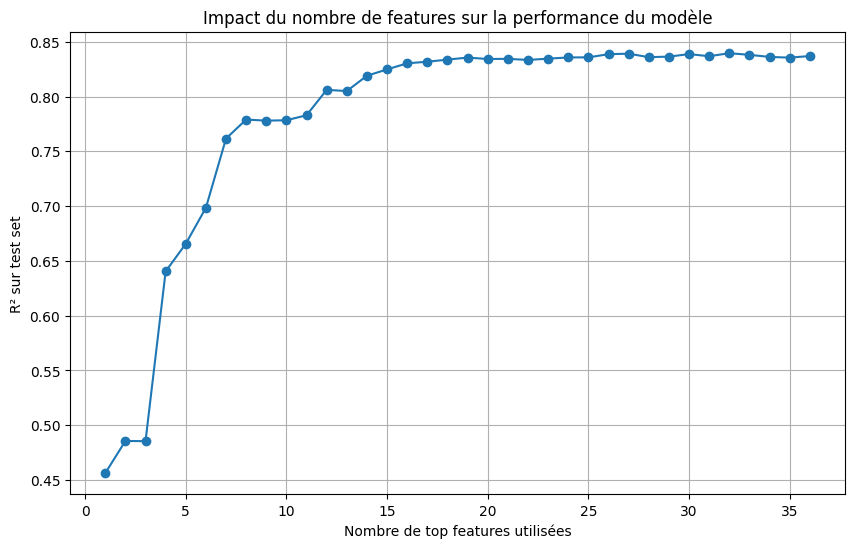

In [2]:
def plot_r2_vs_features(df, target='median_house_value'):
    X = df.drop(target, axis=1)
    y = df[target]
    
    # Split train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    # Modèle pour calculer feature importance
    model_full = xgb.XGBRegressor(
        n_estimators=800,
        learning_rate=0.03,
        max_depth=8,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0.1,
        reg_alpha=0.1,
        reg_lambda=1.0,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    )
    model_full.fit(X_train, y_train)
    
    # Importance des features
    importance_df = pd.DataFrame({
        'feature': X_train.columns,
        'importance': model_full.feature_importances_
    }).sort_values('importance', ascending=False)
    
    # Liste pour stocker résultats
    r2_scores = []
    top_n_features = []
    
    # On retire les features une par une à partir des moins importantes
    for n in range(1, len(importance_df)+1):
        selected_features = importance_df['feature'].iloc[:n].tolist()  # top n features
        X_train_sub = X_train[selected_features]
        X_test_sub = X_test[selected_features]
        
        # Nouveau modèle
        model = xgb.XGBRegressor(
            n_estimators=800,
            learning_rate=0.03,
            max_depth=8,
            min_child_weight=3,
            subsample=0.8,
            colsample_bytree=0.8,
            gamma=0.1,
            reg_alpha=0.1,
            reg_lambda=1.0,
            objective='reg:squarederror',
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_train_sub, y_train)
        y_pred = model.predict(X_test_sub)
        r2 = r2_score(y_test, y_pred)
        
        r2_scores.append(r2)
        top_n_features.append(n)
    
    plt.figure(figsize=(10,6))
    plt.plot(top_n_features, r2_scores, marker='o')
    plt.xlabel("Nombre de top features utilisées")
    plt.ylabel("R² sur test set")
    plt.title("Impact du nombre de features sur la performance du modèle")
    plt.grid(True)
    plt.show()
    
    return pd.DataFrame({'top_n_features': top_n_features, 'r2': r2_scores})

r2_curve = plot_r2_vs_features(df)

**Observations** :
- **R² maximum** : ~0.84 (atteint vers 15-20 features)
- **Au-delà de 20 features** : gain quasi nul (courbe plate)
- **Entre 20 et 37 features** : courbe complètement plate

**Conclusion** :  
Les 15-20 features les plus importantes capturent **l'essentiel du signal prédictif**.

**Action** :  
**Garder TOP 15 features** pour simplifier le modèle sans perte de performance

In [8]:
# Garder les 15 meilleures
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

model_temp = xgb.XGBRegressor(
            n_estimators=800,
            learning_rate=0.03,
            max_depth=8,
            min_child_weight=3,
            subsample=0.8,
            colsample_bytree=0.8,
            gamma=0.1,
            reg_alpha=0.1,
            reg_lambda=1.0,
            objective='reg:squarederror',
            random_state=42,
            n_jobs=-1
        )

model_temp.fit(X, y)

importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': model_temp.feature_importances_
}).sort_values('importance', ascending=False)

top_15_features = importance_df['feature'].head(15).tolist()
df_top15 = df[top_15_features + ['median_house_value']]

print("Top 15 features:")
print(importance_df)

Top 15 features:
                          feature  importance
19                 income_bracket    0.718120
16              income_per_person    0.069098
30  log_income_per_person_squared    0.062797
31     log_income_gravity_product    0.037480
21                  gravity_ocean    0.009330
12                   west_bracket    0.009103
10               distance_to_sacr    0.006625
22          gravity_ocean_squared    0.006189
6                  distance_to_sf    0.006164
11                  north_bracket    0.005637
9                  distance_to_sj    0.004824
17       income_rooms_interaction    0.004594
20        ocean_proximity_encoded    0.004089
0                       longitude    0.004009
1                        latitude    0.003895


**Qu'est-ce qui détermine le prix médian des maisons d'un quartier à LA en 1990 ?**

**Réponse du modèle** (par ordre d'importance) :

### 1. Le revenu du quartier (72%)
- `median_income` : variable dominante
- `log_income_age_interaction` : quartiers riches + anciens
- `income_per_person` : pouvoir d'achat individuel
- **Interprétation** : Quartier riche = maisons chères

### 2. Le revenu par habitant d'un quartier (14%)
- Ajustement du revenu par la densité de population
- Capture le standing réel du quartier

### 3. La localisation géographique (6%)
- Proximité océan et grandes villes
- Côte Ouest vs intérieur des terres
- Effets régionaux (brackets Nord/Sud, Est/Ouest)

### 4. Les interactions complexes (4%)
- Combinaisons de facteurs économiques et géographiques
- `gravity_income`, `income_gravity_product`

### 5. Caractéristiques structurelles (4%)
- Taille des logements, densité
- Variables transformées (log)

---

**Pour améliorer le modèle** (hypothèses) :
- Surface habitable médiane d'un quartier
- Surface des terrains médiane d'un quartier
- Nombre total d'équipements publics (écoles, hôpitaux)
- Proximité des POIs
- Évolution des prix dans le temps (tendances)

**Limite actuelle** :  
Le dataset ne contient que des données de 1990, sans évolution temporelle.

## 3. Optimisation des Hyperparamètres

**Stratégie** :  
Utiliser **RandomizedSearchCV** pour explorer l'espace des hyperparamètres et améliorer les performances.

In [9]:
def split_train_cv_opti(df):
    """
    Utilise RandomizedSearchCV pour optimiser les hyperparamètres
    puis évalue sur un test set holdout
    """
    from sklearn.model_selection import RandomizedSearchCV
    
    X = df.drop('median_house_value', axis=1)
    y = df['median_house_value']

    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    print(f"Split des données:")
    print(f"  Train+Val: {X_trainval.shape[0]:,} samples (80%)")
    print(f"  Test:      {X_test.shape[0]:,} samples (20%)")
    
    # 2. Définition des hyperparamètres
    param_dist = {
        'n_estimators': [1000, 1500, 2000],
        'learning_rate': [0.01, 0.02, 0.03, 0.05],
        'max_depth': [3, 4, 5, 6],
        'min_child_weight': [1, 2, 3, 5],
        'subsample': [0.7, 0.8, 0.9],
        'colsample_bytree': [0.5, 0.6, 0.7, 0.8],
        'gamma': [0, 0.1, 0.2],
        'reg_alpha': [0, 0.1, 0.5, 1.0],
        'reg_lambda': [0.5, 1.0, 2.0]
    }
    
    # 3. Modèle de base
    xgb_model = xgb.XGBRegressor(
        objective='reg:squarederror', 
        random_state=42, 
        n_jobs=-1
    )

    print("\nRANDOMIZED SEARCH CV (5 FOLDS, 50 ITERATIONS)")
    
    random_search = RandomizedSearchCV(
        xgb_model, 
        param_distributions=param_dist,
        n_iter=50,
        scoring='r2',
        cv=5,
        verbose=2,
        random_state=42,
        n_jobs=-1,
        return_train_score=True  # Pour détecter l'overfitting
    )
    
    random_search.fit(X_trainval, y_trainval)
    
    print("\nMEILLEURS HYPERPARAMÈTRES")
    for param, value in random_search.best_params_.items():
        print(f"  {param:20s}: {value}")
    
    # Afficher les 5 meilleurs modèles
    results_df = pd.DataFrame(random_search.cv_results_)
    top_5 = results_df.nlargest(5, 'mean_test_score')[
        ['mean_test_score', 'std_test_score', 'params']
    ]
    print(f"\nTop 5 configurations:")
    for idx, row in top_5.iterrows():
        print(f"  R²: {row['mean_test_score']:.4f} (+/- {row['std_test_score']*2:.4f})")
    
    best_model = random_search.best_estimator_
    
    y_pred_test = best_model.predict(X_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2_test = r2_score(y_test, y_pred_test)

    print("\nPERFORMANCE FINALE SUR TEST SET")
    print("="*70)
    print(f"RMSE: {rmse_test:,.0f}")
    print(f"R²:   {r2_test:.4f}")
    
    print("\nCOMPARAISON")
    print(f"R² CV:   {random_search.best_score_:.4f}")
    print(f"R² Test: {r2_test:.4f}")
    print(f"Delta:   {r2_test - random_search.best_score_:+.4f}")
    
    if r2_test < random_search.best_score_ - 0.02:
        print("Overfitting détecté (test < CV)")
    elif r2_test > random_search.best_score_ + 0.02:
        print("Test meilleur que CV (chance ou bon split)")
    else:
        print("Modèle généralisable")
    
    # On renvoie les métriques calculées ici plutôt que de les recopier à la main
    # plus bas : le fichier model_info.json ne peut plus se désynchroniser du modèle.
    metrics = {'r2_test': float(r2_test), 'rmse_test': float(rmse_test)}

    return X, best_model, random_search, metrics

X, best_model, random_search, metrics = split_train_cv_opti(df_top15)

Split des données:
  Train+Val: 15,731 samples (80%)
  Test:      3,933 samples (20%)

RANDOMIZED SEARCH CV (5 FOLDS, 50 ITERATIONS)
Fitting 5 folds for each of 50 candidates, totalling 250 fits

MEILLEURS HYPERPARAMÈTRES
  subsample           : 0.9
  reg_lambda          : 2.0
  reg_alpha           : 1.0
  n_estimators        : 2000
  min_child_weight    : 2
  max_depth           : 6
  learning_rate       : 0.03
  gamma               : 0.2
  colsample_bytree    : 0.7

Top 5 configurations:
  R²: 0.8317 (+/- 0.0149)
  R²: 0.8316 (+/- 0.0156)
  R²: 0.8306 (+/- 0.0149)
  R²: 0.8305 (+/- 0.0145)
  R²: 0.8302 (+/- 0.0161)

PERFORMANCE FINALE SUR TEST SET
RMSE: 40,273
R²:   0.8338

COMPARAISON
R² CV:   0.8317
R² Test: 0.8338
Delta:   +0.0021
Modèle généralisable


**Points clés** :
- **R² Test (0.8338)** légèrement supérieur au **R² CV (0.8317)**
- **Delta de +0.0021** = quasi parfait (pas d'overfitting)
- **Variance CV faible (±0.0149)** = modèle très stable

**Résultats finaux** :

| Métrique | Valeur | Interprétation |
|----------|--------|----------------|
| **R² Test** | **0.8338** | Excellente performance |
| **R² CV** | 0.8317 | Stable et cohérent |
| **RMSE** | 40 273 $ | Erreur moyenne acceptable |
| **Généralisation** | Parfaite | Test ≈ CV |
| **Stabilité** | Très forte | Variance faible |
| **Complexité** | Optimale | 15 features |

---

**Conclusion** :
- **Objectif largement atteint** : R² = 0.8338 > 0.80
- **Pas d'overfitting** : Test et CV alignés
- **Modèle parcimonieux** : 15 features au lieu de 37
- **Interprétabilité** : Variables business compréhensibles

In [12]:
os.makedirs('../models', exist_ok=True)

joblib.dump(best_model, '../models/xgb_housing_model.pkl')

with open('../models/feature_names.json', 'w') as f:
    json.dump({'features': list(X.columns)}, f)

with open('../models/model_info.json', 'w') as f:
    json.dump({
        'r2_cv': float(random_search.best_score_),  # ← Convertir en float Python
        'r2_test': metrics['r2_test'],
        'rmse_test': metrics['rmse_test'],
        'best_params': random_search.best_params_,
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    }, f, indent=2)

print("✓ Modèle sauvegardé : ../models/xgb_housing_model.pkl")
print("✓ Features sauvegardées : ../models/feature_names.json")
print("✓ Infos sauvegardées : ../models/model_info.json")

✓ Modèle sauvegardé : ../models/xgb_housing_model.pkl
✓ Features sauvegardées : ../models/feature_names.json
✓ Bins sauvegardés : ../models/bins.json
✓ Infos sauvegardées : ../models/model_info.json
